### **Web Scrapping con Scrapy y Data Visualization con Pandas**

### **`> Parte 1`: Web Scrapping utilizando `Scrapy`**

Vamos a scrapear la data de la poblacion desde el sitio:

https://www.worldometers.info/world-population/population-by-country/

#### **Crear la spider**

Vamos a crear la spider:

<center><img src="https://i.postimg.cc/B69GvR7R/ws-465.png"></center>

Luego, debemos editar el archivo `proyecto_poblacion.py` que se crea, con el código que se muestra abajo.

#### **Paso a paso**

Vamos a inspeccionar el sitio: https://www.worldometers.info/world-population/population-by-country/

<center><img src="https://i.postimg.cc/3r0KTz3w/ws-410.png"></center>

Localizamos `todas las filas` de la tabla:

<center><img src="https://i.postimg.cc/hvQx8MF0/ws-415.png"></center>

Localizamos el `nombre del pais` en cada fila:

<center><img src="https://i.postimg.cc/1t2sFrrP/ws-411.png"></center>

Localizamos el `enlace` en cada fila:

<center><img src="https://i.postimg.cc/Gmnm3DRV/ws-420.png"></center>

Ahora vamos a inspeccionar el enlace que se irá generando de manera iterativa: https://www.worldometers.info/world-population/india-population/

En dicho enlace encontramos 3 tablas en el siguiente orden:

1. La población histórica según el año
2. El pronóstico poblacional del 2025 al 2050
3. Principales ciudades según población

<center><img src="https://i.postimg.cc/G2Vr5VnR/ws-87.png"></center>
<center><img src="https://i.postimg.cc/YSXt1jXh/ws-88.png"></center>
<center><img src="https://i.postimg.cc/fydZnCM9/ws-89.png"></center>

Vamos a trabajar con la tabla poblacional histórica:

<center><img src="https://i.postimg.cc/pV3XGhPj/ws-81.png"></center>

Localizamos **`todas las filas de la primera tabla`**, de la tabla de la población histórica según año (por eso el [1]):

<center><img src="https://i.postimg.cc/3JkBpnNy/ws-424.png"></center>

Localizamos **`el año de todas las filas de la primera tabla`**, de la tabla de la población histórica según año (por eso el [1]):

<center><img src="https://i.postimg.cc/y89ypxFs/ws-425.png"></center>

Localizamos **`la población de todas las filas de la primera tabla`**, de la tabla de la población histórica según año (por eso el [1]):

<center><img src="https://i.postimg.cc/tC8zzWnB/ws-426.png"></center>

Localizamos un titulo del cual podamos extraer el `nombre del pais`

<center><img src="https://i.postimg.cc/HkygkqyB/ws-430.png"></center>

#### **Código**

##### **`Forma 1`**

In [ ]:
import scrapy


class WorldmetersCuatroSpider(scrapy.Spider):
    name = "worldmeters_cuatro"
    allowed_domains = ["www.worldometers.info"]
    start_urls = ["https://www.worldometers.info/world-population/population-by-country"]

    def parse(self, response):
        # Extracción de nombres de paises y su población
        filas = response.xpath('//tbody/tr')

        for fila in filas:
            # Obtenemos un 'Enlace relativo' --> /world-population/india-population/
            enlace = fila.xpath('./td/a/@href').get()

            # De manera iterable, se irá enviando una petición por cada enlace que se encuentre
            # y cada página será parseada con la función 'parse_pais()'
            yield response.follow(url=enlace, callback=self.parse_pais)

    # Esta función parseará cada nuevo enlace (página) que se envie como petición:
    # Ejemplo: https://www.worldometers.info/world-population/india-population/
    #          https://www.worldometers.info/world-population/china-population/
    # etc..
    def parse_pais(self, response):
        pais = response.xpath('(//h1)[1]/text()').get(default="Sin nombre")
        filas = response.xpath('(//table[contains(@class, "table")])[1]/tbody/tr')

        for fila in filas:
            anno = fila.xpath('./td[1]/text()').get()
            poblacion = fila.xpath('./td[2]/strong/text()').get()

            # Devuelve los datos extraidos
            # Vamos a devolver un 'Enlace absoluto'
            yield {
                    'pais': pais.strip()[:-11],
                    'anio':anno,
                    'poblacion': poblacion,
                }

##### **`Forma 2`**

In [ ]:
import scrapy


class WorldmetersCuatroSpider(scrapy.Spider):
    name = "worldmeters_cuatro"
    allowed_domains = ["www.worldometers.info"]
    start_urls = ["https://www.worldometers.info/world-population/population-by-country"]

    def parse(self, response):
        # Extracción de nombres de paises y su población
        filas = response.xpath('//tbody/tr')

        for fila in filas:
            nombre_pais = fila.xpath('./td/a/text()').get()
            # Obtenemos un 'Enlace relativo' --> /world-population/india-population/
            enlace = fila.xpath('./td/a/@href').get()

            # De manera iterable, se irá enviando una petición por cada enlace que se encuentre
            # y cada página será parseada con la función 'parse_pais()'
            # Capturamos el nombre del pais y lo almacenamos en 'meta' para despues utilizarlo desde la función 'parse_pais'
            yield response.follow(url=enlace, callback=self.parse_pais, meta={'nombre_pais':nombre_pais})

    # Esta función parseará cada nuevo enlace (página) que se envie como petición:
    # Ejemplo: https://www.worldometers.info/world-population/india-population/
    #          https://www.worldometers.info/world-population/china-population/
    # etc..
    def parse_pais(self, response):
        pais = response.request.meta['nombre_pais']
        filas = response.xpath('(//table[contains(@class, "table")])[1]/tbody/tr')

        for fila in filas:
            anno = fila.xpath('./td[1]/text()').get()
            poblacion = fila.xpath('./td[2]/strong/text()').get()

            # Devuelve los datos extraidos
            # Vamos a devolver un 'Enlace absoluto'
            yield {
                    'pais': pais,
                    'anio':anno,
                    'poblacion': poblacion,
                }

#### **Ejecución**

Nos posicionamos en la ruta correcta y ejecutamos nuestra Spider:

In [ ]:
scrapy crawl proyecto_poblacion

<center><img src="https://i.postimg.cc/JnNCHK90/ws-466.png"></center>

De esta manera obtenemos toda la info que pedimos extraer del website:

<center><img src="https://i.postimg.cc/zvqZCKrj/ws-467.png"></center>

Podriamos exportar toda esta data en un archivo `CSV` escribiendo el siguiente comando:

In [ ]:
scrapy crawl proyecto_poblacion -o population_total.csv

### **`> Parte 2`: Data Visualization con `Pandas`**

#### **1 - Cargamos las librerias que vamos a utilizar**

In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt

#### **2 - Importamos el archivo CSV con la data de poblacion total que scrapeamos**

In [3]:
df_population_raw = pd.read_csv('population_total.csv')
df_population_raw

,pais,anio,poblacion
0,India,2024.0,"1,441,719,852"
1,India,2023.0,"1,428,627,663"
2,India,2022.0,"1,417,173,173"
3,India,2020.0,"1,396,387,127"
4,India,2015.0,"1,322,866,505"
...,...,...,...
4099,Turkey,1975.0,"39,673,590"
4100,Turkey,1970.0,"35,540,990"
4101,Turkey,1965.0,"31,374,536"
4102,Turkey,1960.0,"27,510,980"


#### **3 - Importar el modulo de **`calidad_datos`** para analizar datos estadisticos, nulos y ceros del Dataframe**

In [3]:
from calidad_datos import calidad_datos

d = calidad_datos(df_population_raw)
d = np.round(d, 2)
d

,tipo,nulos,porc_nulos,ceros,porc_ceros,count,unique,top,freq,mean,std,min,25%,50%,75%,max,limit_inf,limit_sup,outliers
anio,float64,7,0.0,0,0.0,4097.0,NaN,NaN,NaN,1994.527703,22.748482,1955.0,1975.0,1995.0,2017.0,2024.0,1960.40498,2028.650426,466
pais,object,0,0.0,0,0.0,4104,234,Faeroe Islands,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
poblacion,object,7,0.0,0,0.0,4097,4091,"7,635",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


#### **4 - Analizar la data**

In [14]:
df_population_raw.columns

Index(['pais', 'anio', 'poblacion'], dtype='object')

In [15]:
df_population_raw.columns.values

array(['pais', 'anio', 'poblacion'], dtype=object)

In [16]:
df_population_raw.shape

(4104, 3)

In [17]:
df_population_raw.isna().sum()

pais         0
anio         7
poblacion    7
dtype: int64

El pais de `Micronesia` es aquel que tiene los 7 valores `NaN`

In [9]:
df_population_raw.loc[df_population_raw.anio.isnull(), 'pais']

1438    Micronesia
1439    Micronesia
1447    Micronesia
1448    Micronesia
1449    Micronesia
1450    Micronesia
1451    Micronesia
Name: pais, dtype: object

In [ ]:
df_population_raw.loc[df_population_raw.pais=='Micronesia', ['anio', 'poblacion']]

,anio,poblacion
1438,NaN,NaN
1439,NaN,NaN
1447,NaN,NaN
1448,NaN,NaN
1449,NaN,NaN
1450,NaN,NaN
1451,NaN,NaN


#### **5 - Filtrar los datos vacios**

##### `Forma 1`

Filtramos todos los datos que no tengan poblacion, dejando solo asi aquellos paises que si tengan este dato:

In [4]:
df_population_raw = df_population_raw[df_population_raw['poblacion'].str.len() > 0]

##### `Forma 2`

Filtramos todos los datos que no tengan poblacion, dejando solo asi aquellos paises que si tengan este dato:

In [33]:
df_population_raw  = df_population_raw[~df_population_raw.poblacion.isnull()]

##### `Forma 3` - Utilizando RegEx

`na=True` significa que NaN:s devolverá True.

In [4]:
#df_population_raw[~df_population_raw['poblacion'].str.contains(r'^(?:\s+)?$', na=True, regex=True)]
#df_population_raw[~df_population_raw['poblacion'].str.contains(r'^(?:\s+)', na=True, regex=True)]
df_population_raw = df_population_raw[~df_population_raw['poblacion'].str.contains(r'(?:\s+)', na=True, regex=True)]

##### `Forma 4` - Utilizando dropna()

In [ ]:
# dropear valores null solo de la columna "poblacion"
df_population_raw.dropna(subset=['poblacion'])

In [4]:
# dropear valores null de cada columna
df_population_raw.dropna(axis=0, how="any", inplace=True)
df_population_raw.shape

(4097, 3)

#### **6 - Modificamos el valor de las columnas `Anio` y `Poblacion`**

El valor del año es del tipo `float` y aparece como decimal. Vamos a convertirlo en `int`:

In [5]:
df_population_raw['anio'] = df_population_raw['anio'].astype('int64')

El valor de la columna poblacion es del tipo `object`. Vamos a convertirlo en `int`. Sin embargo, debemos observar que el valor del dato tiene comas  --> `1,441,719,852`. Por tanto, vamos a remover las comas y solo dejar el numero:

In [6]:
df_population_raw['poblacion'] = df_population_raw['poblacion'].str.replace(',', '')
df_population_raw['poblacion'] = df_population_raw['poblacion'].astype('int64')

In [20]:
df_population_raw.dtypes

pais         object
anio          int64
poblacion     int64
dtype: object

In [21]:
df_population_raw

,pais,anio,poblacion
0,India,2024,1441719852
1,India,2023,1428627663
2,India,2022,1417173173
3,India,2020,1396387127
4,India,2015,1322866505
...,...,...,...
4099,Turkey,1975,39673590
4100,Turkey,1970,35540990
4101,Turkey,1965,31374536
4102,Turkey,1960,27510980


#### **7 - Pivotear el dataframe**

In [7]:
df_pivot = df_population_raw.pivot(index='anio', 
                                   columns='pais',
                                   values='poblacion')

df_pivot

pais,Afghanistan,Albania,Algeria,American Samoa,Andorra,Angola,Anguilla,Antigua and Barbuda,Argentina,Armenia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,Wallis & Futuna,Western Sahara,Yemen,Zambia,Zimbabwe
anio,,,,,,,,,,,,,,,,,,,,,
1955,7971931.0,1453730.0,10242288.0,19826.0,6116.0,4938118.0,5752.0,50264.0,18700686.0,1604376.0,...,2366209.0,7141923.0,56770.0,6752139.0,28263031.0,9616.0,20690.0,5091603.0,2677209.0,3263625.0
1960,8622466.0,1711189.0,11394307.0,20085.0,9443.0,5357195.0,5752.0,55342.0,20349744.0,1904148.0,...,2529021.0,8372311.0,64608.0,8156937.0,32718461.0,8780.0,33023.0,5542459.0,3119430.0,3806310.0
1965,9565147.0,2009789.0,12381256.0,23391.0,13563.0,5736582.0,6018.0,59644.0,22053661.0,2234051.0,...,2680427.0,10130096.0,74677.0,9688138.0,37466077.0,8887.0,51206.0,6097298.0,3658024.0,4447149.0
1970,10752971.0,2324731.0,13795915.0,27075.0,19860.0,6029700.0,6283.0,64517.0,23842803.0,2534377.0,...,2790265.0,12011361.0,87019.0,11355475.0,41928849.0,9377.0,76371.0,6843607.0,4281671.0,5202918.0
1975,12157386.0,2650122.0,15724692.0,29573.0,27640.0,7032713.0,6463.0,64035.0,25875558.0,2830798.0,...,2871947.0,13894347.0,102010.0,13176387.0,46969616.0,9723.0,66865.0,7855657.0,4931249.0,6097083.0
1980,12486631.0,2941651.0,18739378.0,32886.0,35611.0,8330047.0,6560.0,64889.0,28024803.0,3135123.0,...,2953750.0,15947129.0,118156.0,15210443.0,52968270.0,11315.0,116775.0,9204938.0,5720438.0,7049926.0
1985,10512221.0,3171725.0,22132905.0,39663.0,43809.0,9970621.0,6907.0,65048.0,30287112.0,3300896.0,...,3024218.0,18063201.0,133119.0,17402304.0,59811313.0,12794.0,150190.0,11036918.0,6686449.0,8690515.0
1990,10694796.0,3295066.0,25518074.0,47818.0,53569.0,11828638.0,8316.0,63328.0,32637657.0,3556539.0,...,3117012.0,20579100.0,150882.0,19750579.0,66912613.0,13454.0,178529.0,13375121.0,7686401.0,10113893.0
1995,16418912.0,3284364.0,28478022.0,53401.0,62928.0,13912253.0,9601.0,68398.0,34946110.0,3322782.0,...,3208300.0,23026206.0,170612.0,22107286.0,73759110.0,14180.0,208381.0,16103339.0,8684135.0,10994041.0


In [23]:
df_pivot.dtypes

pais
Afghanistan        float64
Albania            float64
Algeria            float64
American Samoa     float64
Andorra            float64
                    ...   
Wallis & Futuna    float64
Western Sahara     float64
Yemen              float64
Zambia             float64
Zimbabwe           float64
Length: 233, dtype: object

In [24]:
df_pivot.index

Index([1955, 1960, 1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010,
       2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype='int64', name='anio')

Vamos a quitar las filas que corresponden a los años 2016, 2017, 2018, 2019 y 2021. Vamos a dejar años múltiplos de 5:

In [8]:
# slice column labels
anios = [2016, 2017, 2018, 2019, 2021]

df_pivot.loc[anios]

pais,Afghanistan,Albania,Algeria,American Samoa,Andorra,Angola,Anguilla,Antigua and Barbuda,Argentina,Armenia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,Wallis & Futuna,Western Sahara,Yemen,Zambia,Zimbabwe
anio,,,,,,,,,,,,,,,,,,,,,
2016,NaN,NaN,NaN,50448.0,72540.0,NaN,14813.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,12060.0,NaN,NaN,NaN,NaN
2017,NaN,NaN,NaN,49463.0,73837.0,NaN,15015.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,11936.0,NaN,NaN,NaN,NaN
2018,NaN,NaN,NaN,48424.0,75013.0,NaN,15181.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,11816.0,NaN,NaN,NaN,NaN
2019,NaN,NaN,NaN,47321.0,76343.0,NaN,15380.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,11714.0,NaN,NaN,NaN,NaN
2021,NaN,NaN,NaN,45035.0,79034.0,NaN,15753.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,11627.0,NaN,NaN,NaN,NaN


In [9]:
df_pivot.drop(index=anios, inplace=True)

In [10]:
df_pivot

pais,Afghanistan,Albania,Algeria,American Samoa,Andorra,Angola,Anguilla,Antigua and Barbuda,Argentina,Armenia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,Wallis & Futuna,Western Sahara,Yemen,Zambia,Zimbabwe
anio,,,,,,,,,,,,,,,,,,,,,
1955,7971931.0,1453730.0,10242288.0,19826.0,6116.0,4938118.0,5752.0,50264.0,18700686.0,1604376.0,...,2366209.0,7141923.0,56770.0,6752139.0,28263031.0,9616.0,20690.0,5091603.0,2677209.0,3263625.0
1960,8622466.0,1711189.0,11394307.0,20085.0,9443.0,5357195.0,5752.0,55342.0,20349744.0,1904148.0,...,2529021.0,8372311.0,64608.0,8156937.0,32718461.0,8780.0,33023.0,5542459.0,3119430.0,3806310.0
1965,9565147.0,2009789.0,12381256.0,23391.0,13563.0,5736582.0,6018.0,59644.0,22053661.0,2234051.0,...,2680427.0,10130096.0,74677.0,9688138.0,37466077.0,8887.0,51206.0,6097298.0,3658024.0,4447149.0
1970,10752971.0,2324731.0,13795915.0,27075.0,19860.0,6029700.0,6283.0,64517.0,23842803.0,2534377.0,...,2790265.0,12011361.0,87019.0,11355475.0,41928849.0,9377.0,76371.0,6843607.0,4281671.0,5202918.0
1975,12157386.0,2650122.0,15724692.0,29573.0,27640.0,7032713.0,6463.0,64035.0,25875558.0,2830798.0,...,2871947.0,13894347.0,102010.0,13176387.0,46969616.0,9723.0,66865.0,7855657.0,4931249.0,6097083.0
1980,12486631.0,2941651.0,18739378.0,32886.0,35611.0,8330047.0,6560.0,64889.0,28024803.0,3135123.0,...,2953750.0,15947129.0,118156.0,15210443.0,52968270.0,11315.0,116775.0,9204938.0,5720438.0,7049926.0
1985,10512221.0,3171725.0,22132905.0,39663.0,43809.0,9970621.0,6907.0,65048.0,30287112.0,3300896.0,...,3024218.0,18063201.0,133119.0,17402304.0,59811313.0,12794.0,150190.0,11036918.0,6686449.0,8690515.0
1990,10694796.0,3295066.0,25518074.0,47818.0,53569.0,11828638.0,8316.0,63328.0,32637657.0,3556539.0,...,3117012.0,20579100.0,150882.0,19750579.0,66912613.0,13454.0,178529.0,13375121.0,7686401.0,10113893.0
1995,16418912.0,3284364.0,28478022.0,53401.0,62928.0,13912253.0,9601.0,68398.0,34946110.0,3322782.0,...,3208300.0,23026206.0,170612.0,22107286.0,73759110.0,14180.0,208381.0,16103339.0,8684135.0,10994041.0


#### **8 - Seleccionar columnas (paises sudamericanos)**

In [11]:
df_pivot = df_pivot[['Chile', 'Argentina', 'Brazil', 'Peru', 'Bolivia', 'Uruguay']]
df_pivot

pais,Chile,Argentina,Brazil,Peru,Bolivia,Uruguay
anio,,,,,,
1955,7323194.0,18700686.0,62701031.0,8825897.0,3357923.0,2366209.0
1960,8141820.0,20349744.0,73092515.0,10172207.0,3707515.0,2529021.0
1965,8994936.0,22053661.0,84623747.0,11781581.0,4115511.0,2680427.0
1970,9820481.0,23842803.0,96369875.0,13562371.0,4585693.0,2790265.0
1975,10639531.0,25875558.0,108700515.0,15441497.0,5127776.0,2871947.0
1980,11469828.0,28024803.0,122288383.0,17492406.0,5736088.0,2953750.0
1985,12326396.0,30287112.0,136783180.0,19746610.0,6385630.0,3024218.0
1990,13342868.0,32637657.0,150706446.0,22109099.0,7096194.0,3117012.0
1995,14416796.0,34946110.0,163515328.0,24449055.0,7841471.0,3208300.0


#### **9 - Generar visualizaciones (Plotear)**

##### **`Gráfico de lineas`**

<Axes: title={'center': 'Población (1955-2024)'}, xlabel='Años', ylabel='Poblacion'>

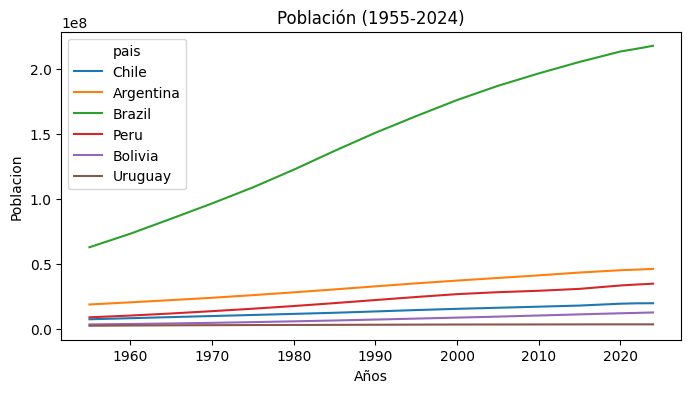

In [12]:
df_pivot.plot(kind='line',
              xlabel='Años', ylabel='Poblacion',
              title='Población (1955-2024)',
              figsize=(8,4))

##### **`Gráfico de barras`**

In [37]:
# seleccionamos solo un año (2024)
df_pivot_2024 = df_pivot[df_pivot.index.isin([2024])]

In [38]:
# Transponemos el Dataframe de filas a columnas o viceversa
df_pivot_2024 = df_pivot_2024.T

df_pivot_2024

anio,2024
pais,
Chile,19658839.0
Argentina,46057866.0
Brazil,217637297.0
Peru,34683444.0
Bolivia,12567336.0
Uruguay,3423316.0


<Axes: title={'center': 'Poblacion en 2024'}, xlabel='Paises', ylabel='Poblacion'>

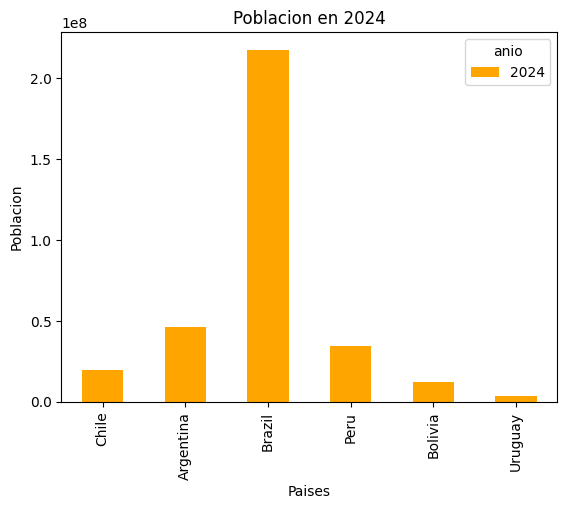

In [43]:
df_pivot_2024.plot(kind='bar', color='orange',
                   xlabel='Paises', ylabel='Poblacion',
                   title='Poblacion en 2024')

##### **`Gráfico de barras agrupadas`**

In [44]:
# seleccionamos algunos años
df_pivot_sample = df_pivot[df_pivot.index.isin([1980, 1990, 2000, 2010, 2020])]

<Axes: xlabel='Years', ylabel='Population'>

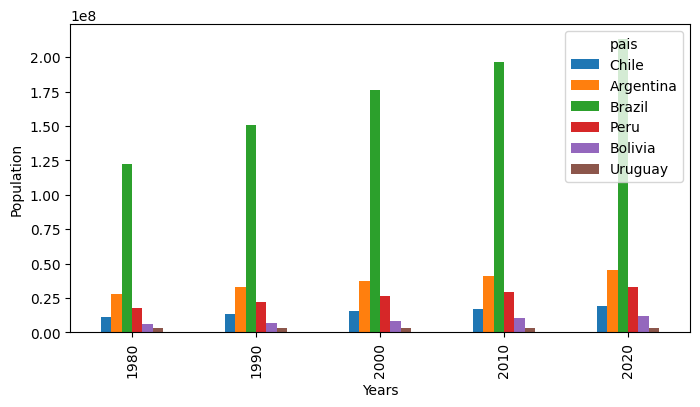

In [45]:
df_pivot_sample.plot(kind='bar',
                     xlabel='Years', ylabel='Population',
                     figsize=(8,4))

##### **`Gráfico de torta`**

In [46]:
# Cambiamos el nombre de una columna
df_pivot_2024.rename(columns={2024:'2024'}, inplace=True)

<Axes: title={'center': 'Población en 2024 (%)'}, ylabel='2024'>

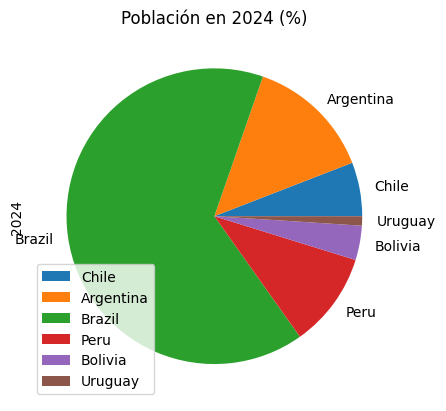

In [47]:
df_pivot_2024.plot(kind='pie',
                   y='2024',
                   title='Población en 2024 (%)')

##### **`Boxplot`**

**Boxplot individual**

<Axes: ylabel='Population'>

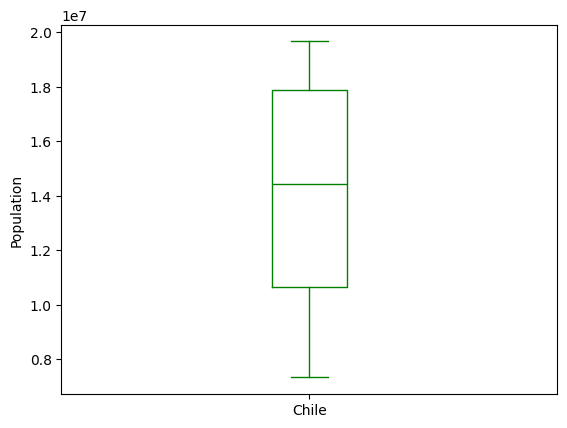

In [48]:
df_pivot['Chile'].plot(kind='box', 
                       color='green', 
                       ylabel='Population')

**Boxplot múltiple**

<Axes: xlabel='pais', ylabel='poblacion'>

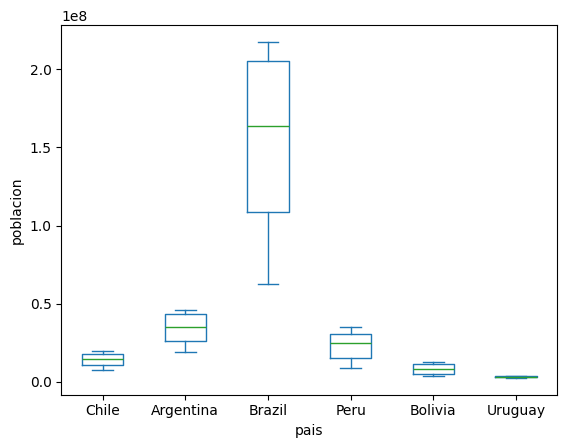

In [49]:
df_pivot.plot(kind='box', 
              xlabel='pais',
              ylabel='poblacion')

##### **`Histograma`**

<Axes: xlabel='poblacion', ylabel='Frequency'>

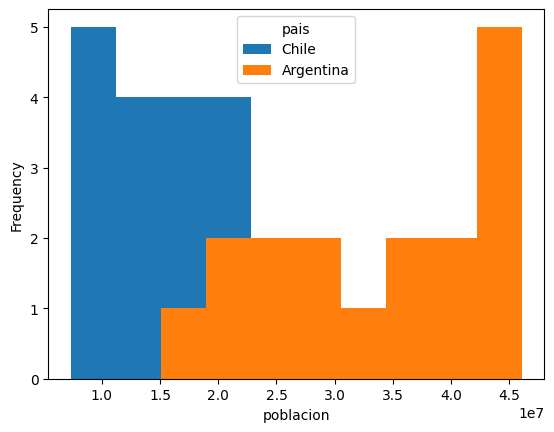

In [50]:
df_pivot[['Chile', 'Argentina']].plot(kind='hist',
                                      xlabel='poblacion')

##### **`Diagrama de dispersión`**

<Axes: xlabel='anio', ylabel='poblacion'>

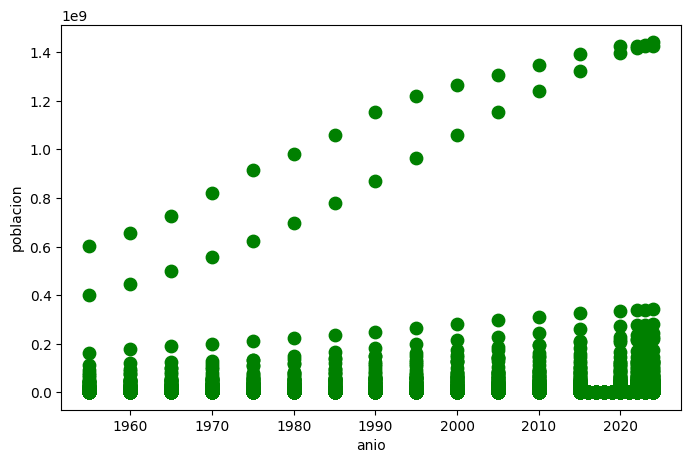

In [53]:
df_population_raw.plot(kind='scatter',
                       x='anio',
                       y='poblacion',
                       figsize=(8,5),
                       color='green',
                       s=80)